In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("C:\\Users\\user\\Documents\\프로젝트\\3차_Job Stress dataset\\main_repo\\DATA\\dataset.csv")

# 타겟 생성

In [3]:
# 직무 스트레스 항목
df['Occupational_Stress_Sum'] = df[['OS1', 'OS2', 'OS3', 'OS4', 'OS5', 'OS6', 'OS7', 'OS8',
                                    'OS9', 'OS10', 'OS11', 'OS12', 'OS13', 'OS14',
                                    'OS15', 'OS16', 'OS17', 'OS18', 'OS19',
                                    'OS20', 'OS21', 'OS22', 'OS23',
                                    'OS24', 'OS25', 'OS26', 'OS27', 'OS28',
                                    'OS29', 'OS30', 'OS31',
                                    'OS32', 'OS33', 'OS34', 'OS35',
                                    'OS36', 'OS37', 'OS38', 'OS39',
                                    'OS40', 'OS41']].sum(axis=1)

# 정규화
scaler = MinMaxScaler()
df['Occupational_Stress_Normalized'] = scaler.fit_transform(df[['Occupational_Stress_Sum']])

# 0.5기준 이진화 
df['Occupational_Stress_Target'] = df['Occupational_Stress_Normalized'].apply(lambda x: 0 if x <= 0.5 else 1)



# 데이터 전처리

In [4]:
df.drop(columns=['OS1', 'OS2', 'OS3', 'OS4', 'OS5', 'OS6', 'OS7', 'OS8', 'OS9', 'OS10', 'OS11', 'OS12', 'OS13', 'OS14', 'OS15', 'OS16', 'OS17', 'OS18', 'OS19', 'OS20', 'OS21', 'OS22', 'OS23', 'OS24', 'OS25', 'OS26', 'OS27', 'OS28', 'OS29', 'OS30', 'OS31', 'OS32', 'OS33', 'OS34', 'OS35', 'OS36', 'OS37', 'OS38', 'OS39', 'OS40', 'OS41'], inplace=True)
df = df.drop(columns=['Occupational_Stress_Sum', 'Occupational_Stress_Normalized'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 55 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          309 non-null    int64
 1   Age                         309 non-null    int64
 2   Religion                    309 non-null    int64
 3   Ethnicity                   309 non-null    int64
 4   Marital status              309 non-null    int64
 5   Marriage period             309 non-null    int64
 6   No. of children             309 non-null    int64
 7   Educational level           309 non-null    int64
 8   Employment status           309 non-null    int64
 9   Working period              309 non-null    int64
 10  Household income            309 non-null    int64
 11  Sperm quality               309 non-null    int64
 12  JS1                         309 non-null    int64
 13  JS2                         309 non-null    int64
 14  JS3       

In [6]:
df.head()

,ID,Age,Religion,Ethnicity,Marital status,Marriage period,No. of children,Educational level,Employment status,Working period,...,JS34,JS35,JS36,JP1,JP2,JP3,JP4,JP5,JP6,Occupational_Stress_Target
0,1,2,1,1,1,1,1,6,1,4,...,4,4,4,4,4,4,2,5,5,1
1,2,2,1,1,1,2,1,6,1,3,...,3,5,5,5,5,4,5,5,5,1
2,3,2,1,1,1,2,1,6,1,5,...,5,5,5,5,5,5,5,5,5,1
3,4,3,1,1,2,1,2,5,1,5,...,5,5,5,2,2,2,4,5,5,1
4,5,2,1,1,1,1,1,6,1,3,...,5,5,5,5,5,5,5,5,5,1


In [7]:
df.describe()

,ID,Age,Religion,Ethnicity,Marital status,Marriage period,No. of children,Educational level,Employment status,Working period,...,JS34,JS35,JS36,JP1,JP2,JP3,JP4,JP5,JP6,Occupational_Stress_Target
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,...,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,155.000000,2.165049,1.084142,1.129450,1.100324,1.883495,1.323625,6.019417,1.042071,4.433657,...,3.922330,3.789644,3.705502,4.207120,4.194175,4.090615,4.042071,4.239482,4.388350,0.634304
std,89.344838,0.604589,0.433246,0.560676,0.300918,0.772510,0.557236,1.164802,0.257694,0.882532,...,0.911927,0.979211,1.032273,0.722425,0.650548,0.754774,0.861238,0.765062,0.682333,0.482406
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,0.000000
25%,78.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000,4.000000,...,4.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,0.000000
50%,155.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,6.000000,1.000000,5.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,1.000000
75%,232.000000,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,7.000000,1.000000,5.000000,...,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000
max,309.000000,5.000000,4.000000,5.000000,2.000000,3.000000,3.000000,9.000000,3.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000


In [9]:
df.dtypes

ID                            int64
Age                           int64
Religion                      int64
Ethnicity                     int64
Marital status                int64
Marriage period               int64
No. of children               int64
Educational level             int64
Employment status             int64
Working period                int64
Household income              int64
Sperm quality                 int64
JS1                           int64
JS2                           int64
JS3                           int64
JS4                           int64
JS5                           int64
JS6                           int64
JS7                           int64
JS8                           int64
JS9                           int64
JS10                          int64
JS11                          int64
JS12                          int64
JS13                          int64
JS14                          int64
JS15                          int64
JS16                        

In [10]:
df.value_counts()

ID   Age  Religion  Ethnicity  Marital status  Marriage period  No. of children  Educational level  Employment status  Working period  Household income  Sperm quality  JS1  JS2  JS3  JS4  JS5  JS6  JS7  JS8  JS9  JS10  JS11  JS12  JS13  JS14  JS15  JS16  JS17  JS18  JS19  JS20  JS21  JS22  JS23  JS24  JS25  JS26  JS27  JS28  JS29  JS30  JS31  JS32  JS33  JS34  JS35  JS36  JP1  JP2  JP3  JP4  JP5  JP6  Occupational_Stress_Target
1    2    1         1          1               1                1                6                  1                  4               7                 3              4    4    4    5    5    4    4    4    5    5     5     4     5     3     2     5     4     5     4     5     4     2     3     3     4     4     5     5     5     4     5     5     5     4     4     4     4    4    4    2    5    5    1                             1
205  2    1         1          1               2                1                5                  1                  5           

In [11]:
df.isnull().sum()

ID                            0
Age                           0
Religion                      0
Ethnicity                     0
Marital status                0
Marriage period               0
No. of children               0
Educational level             0
Employment status             0
Working period                0
Household income              0
Sperm quality                 0
JS1                           0
JS2                           0
JS3                           0
JS4                           0
JS5                           0
JS6                           0
JS7                           0
JS8                           0
JS9                           0
JS10                          0
JS11                          0
JS12                          0
JS13                          0
JS14                          0
JS15                          0
JS16                          0
JS17                          0
JS18                          0
JS19                          0
JS20    

In [ ]:
# 데이터 분할

X = df.drop(['Occupational_Stress_Target'], axis=1)  # Features
y = df['Occupational_Stress_Target']  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = y, random_state=42)


In [13]:
# 정규화

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

ID - Number of Outliers: 0


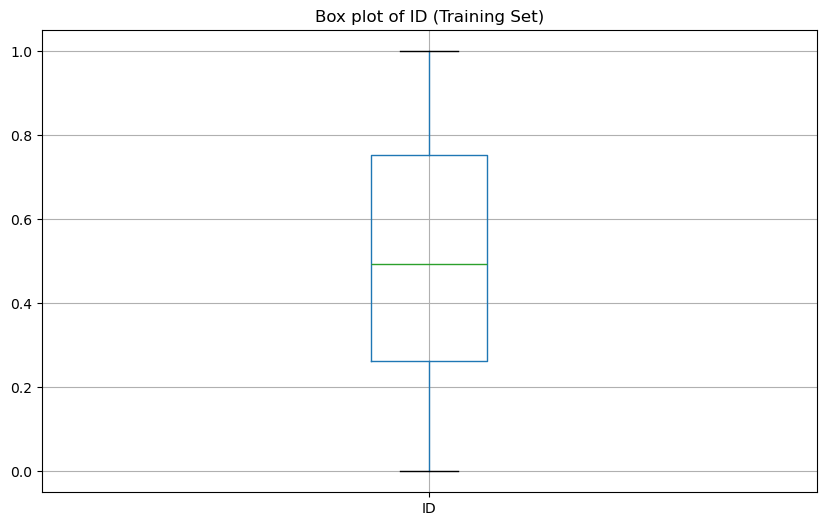

Age - Number of Outliers: 0


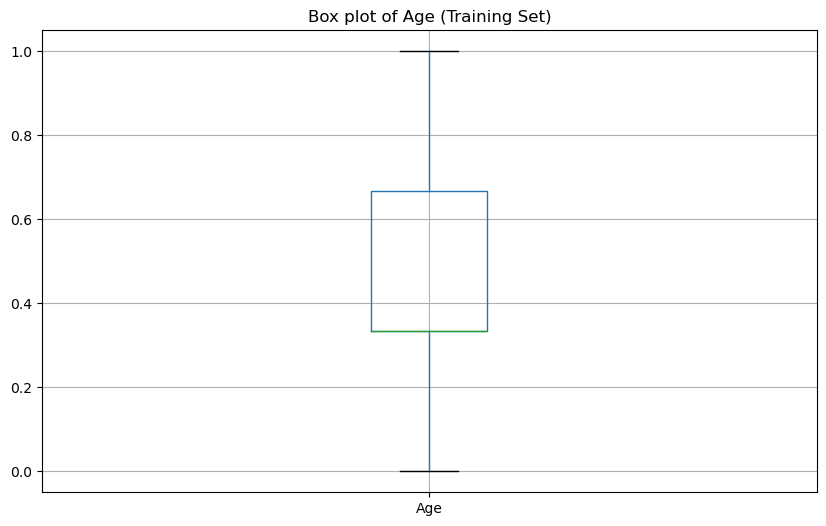

Religion - Number of Outliers: 11


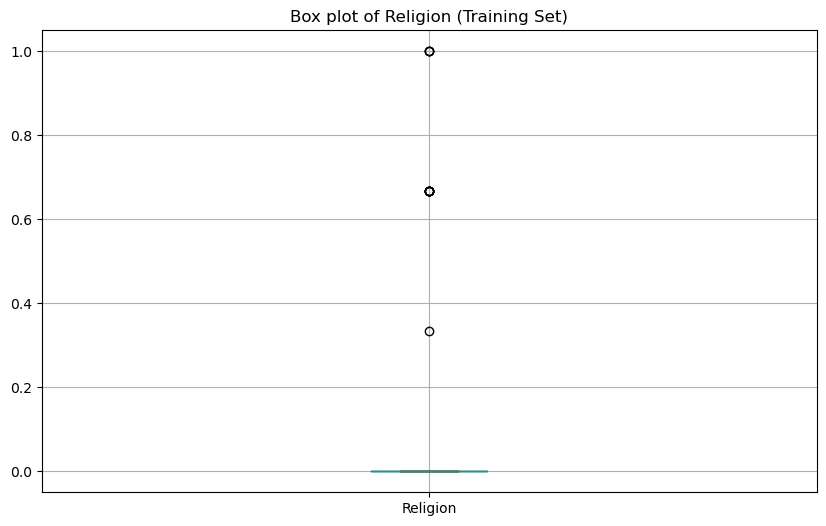

Ethnicity - Number of Outliers: 16


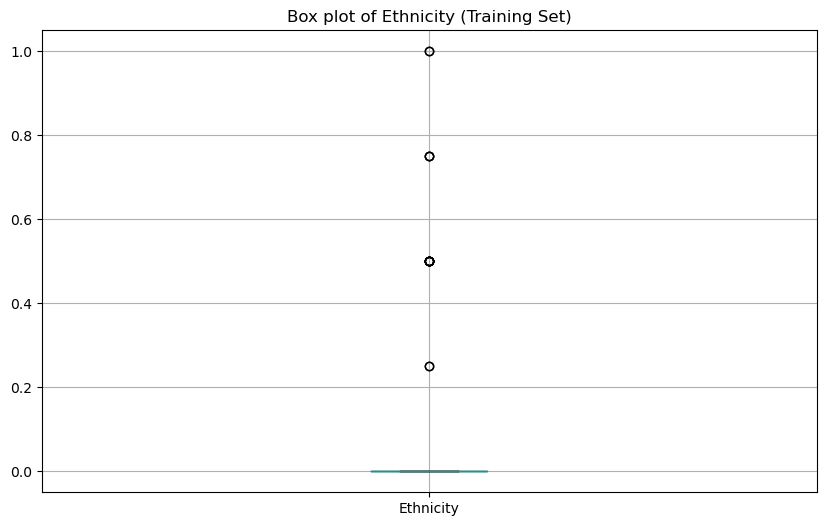

Marital status - Number of Outliers: 25


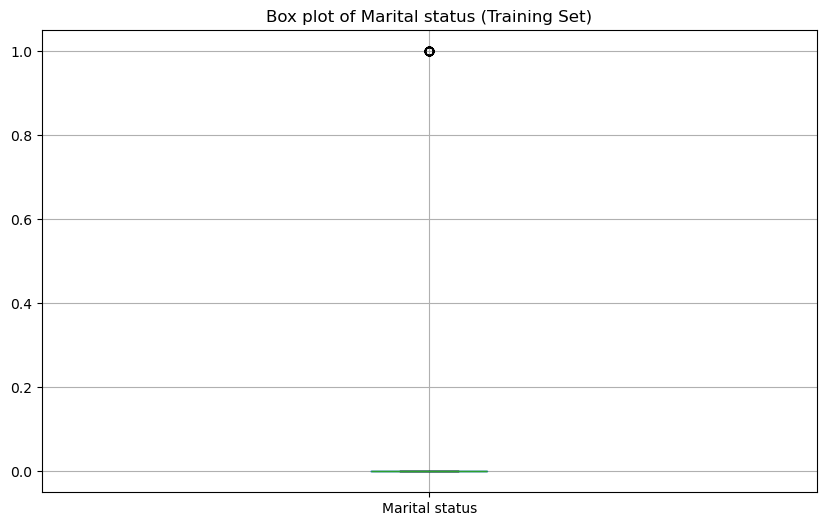

Marriage period - Number of Outliers: 0


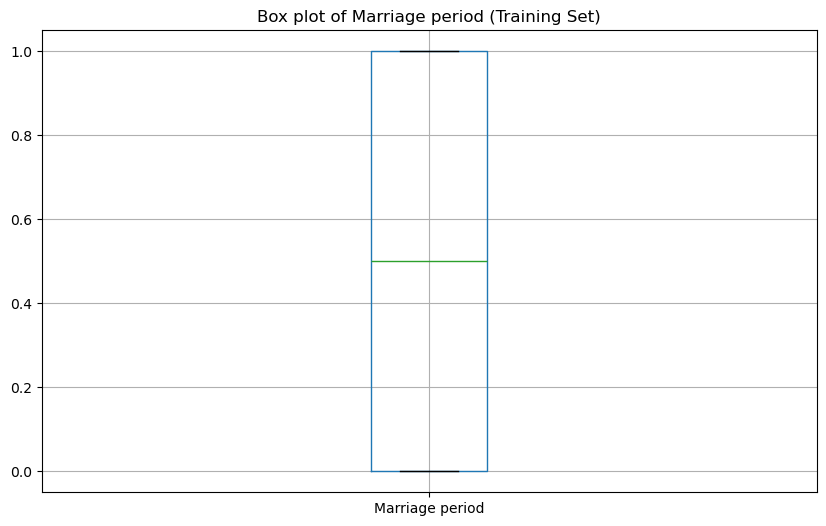

No. of children - Number of Outliers: 0


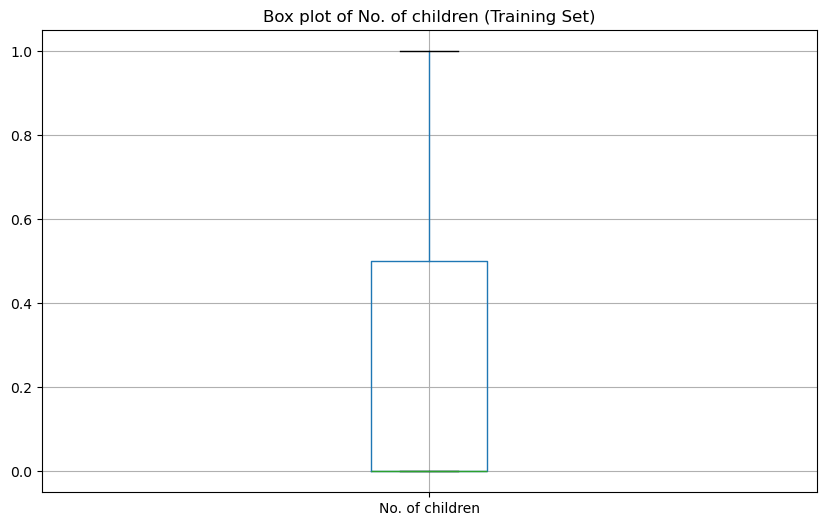

Educational level - Number of Outliers: 0


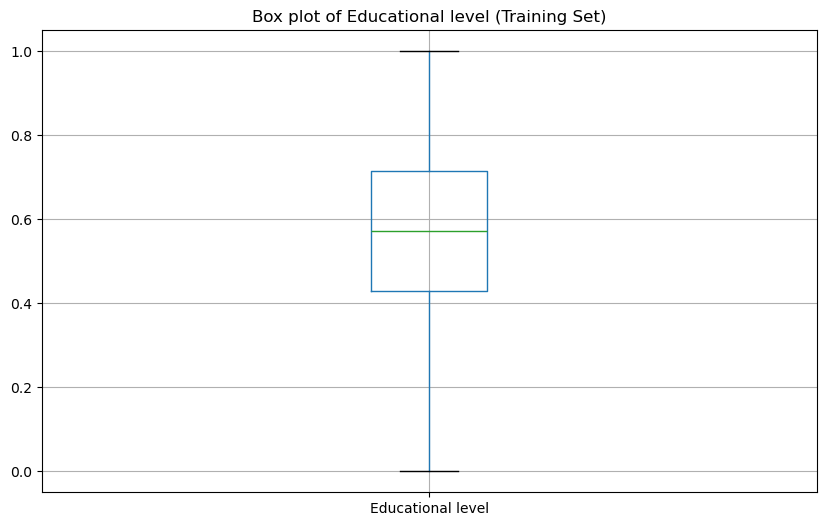

Employment status - Number of Outliers: 8


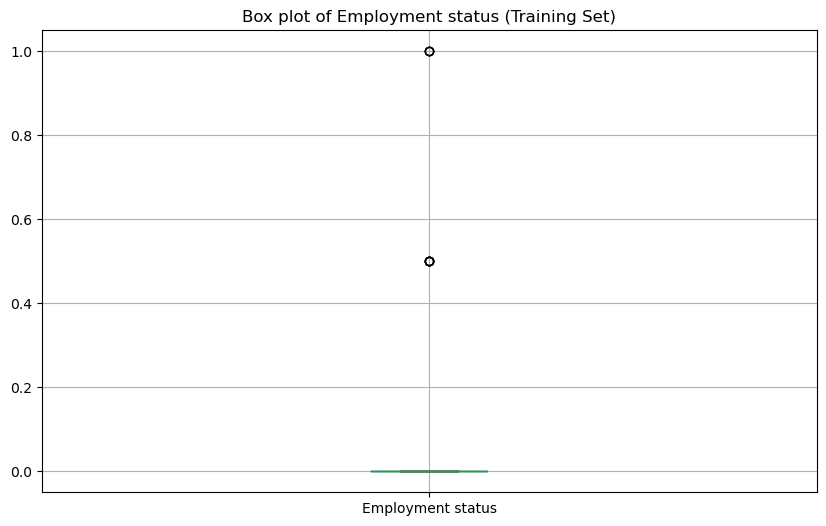

Working period - Number of Outliers: 13


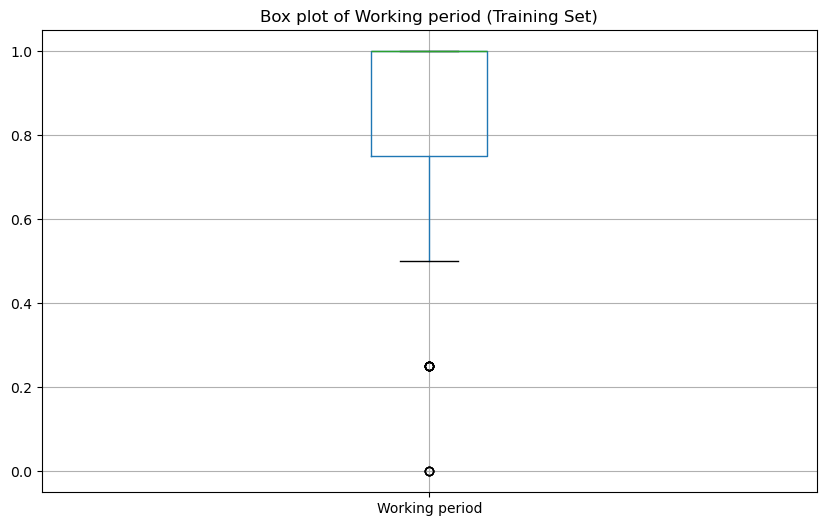

Household income - Number of Outliers: 0


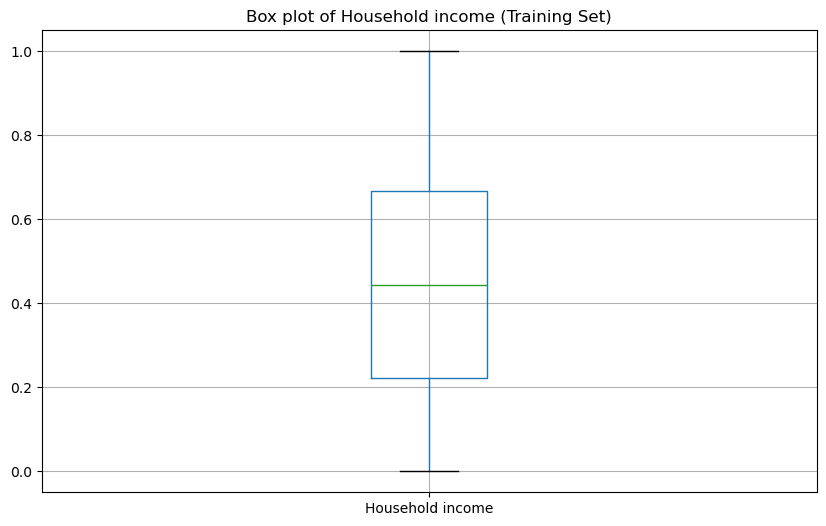

Sperm quality - Number of Outliers: 29


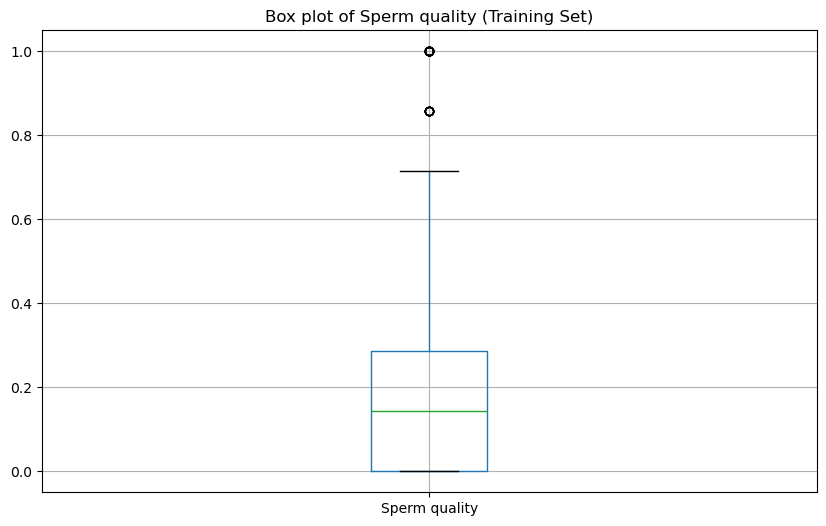

JS1 - Number of Outliers: 19


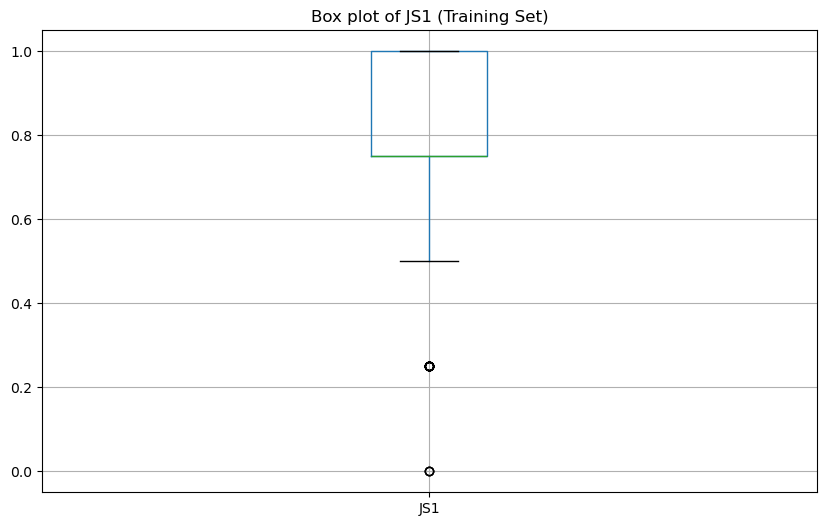

JS2 - Number of Outliers: 0


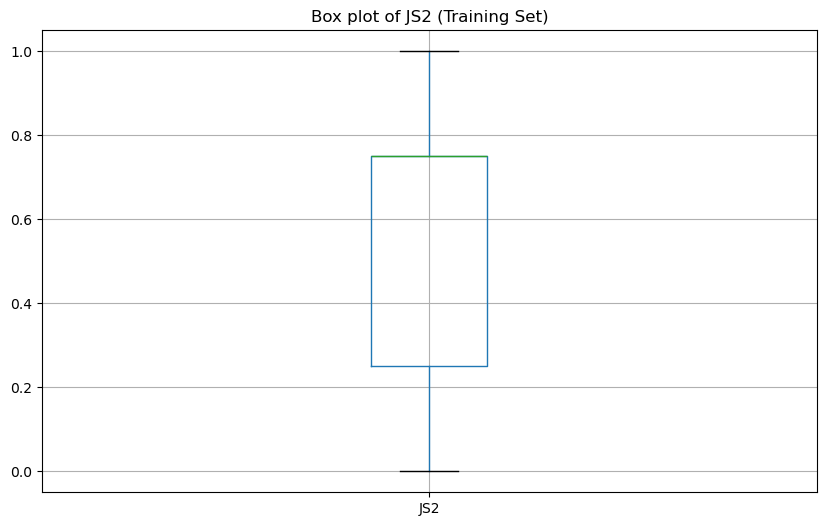

JS3 - Number of Outliers: 0


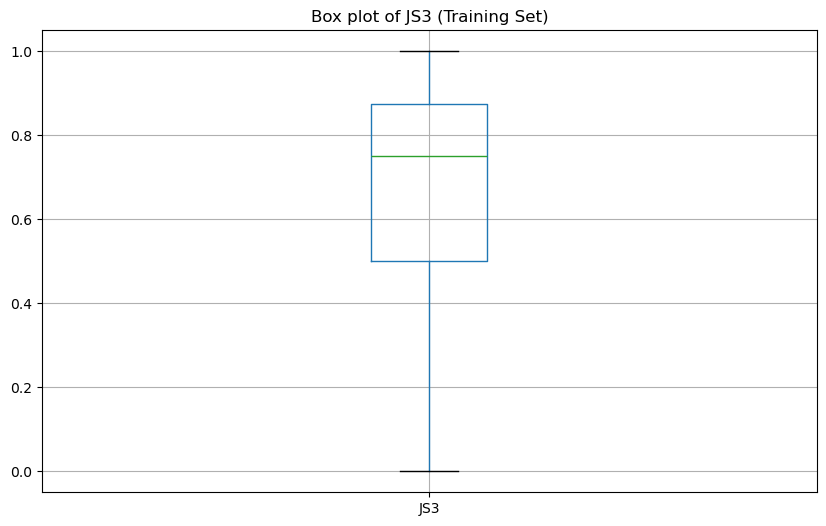

JS4 - Number of Outliers: 9


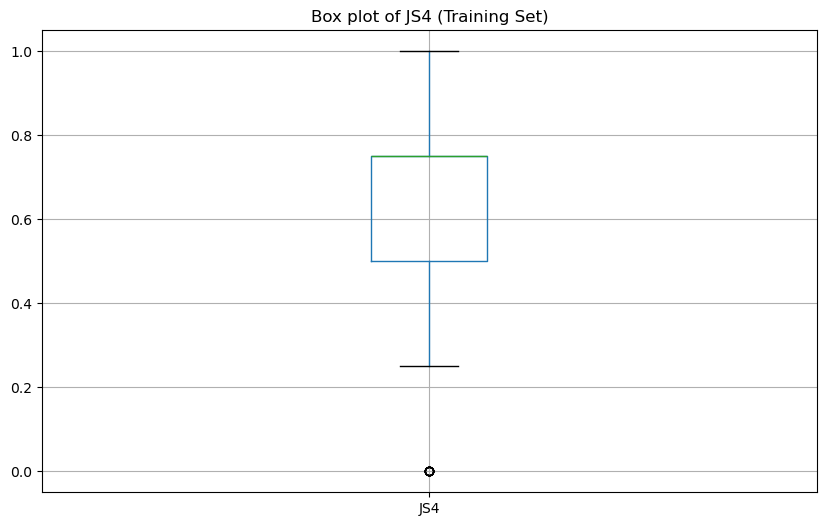

JS5 - Number of Outliers: 0


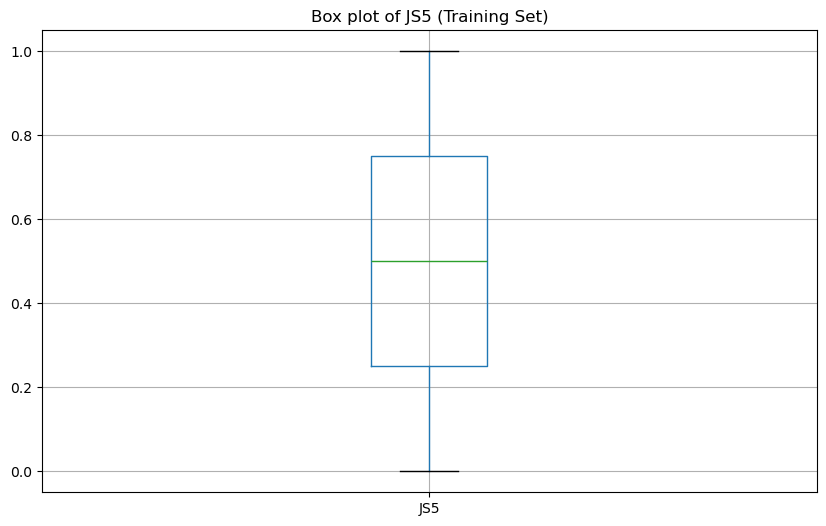

JS6 - Number of Outliers: 10


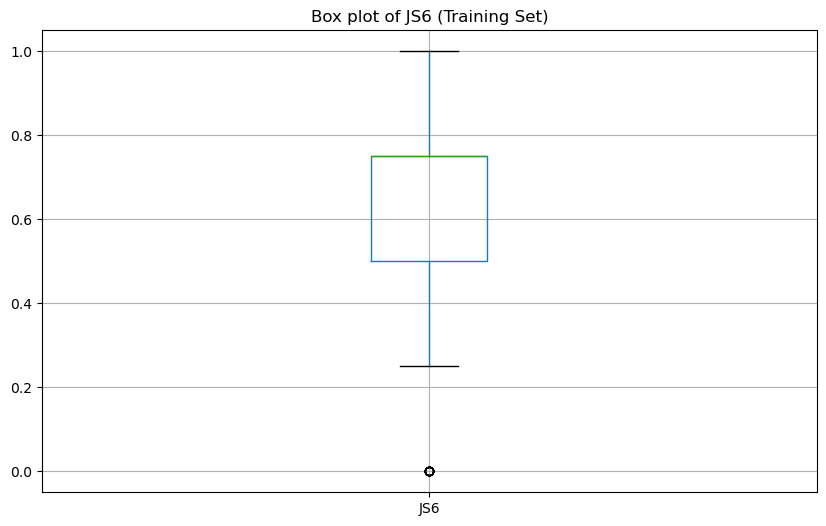

JS7 - Number of Outliers: 0


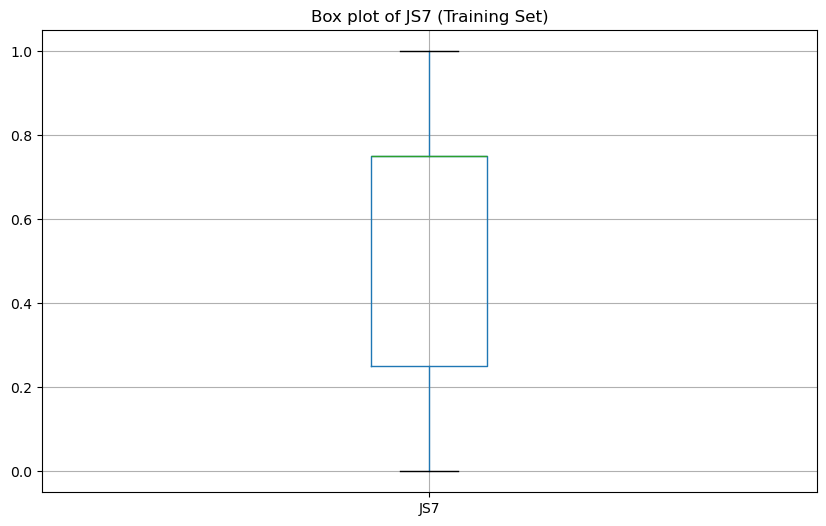

JS8 - Number of Outliers: 3


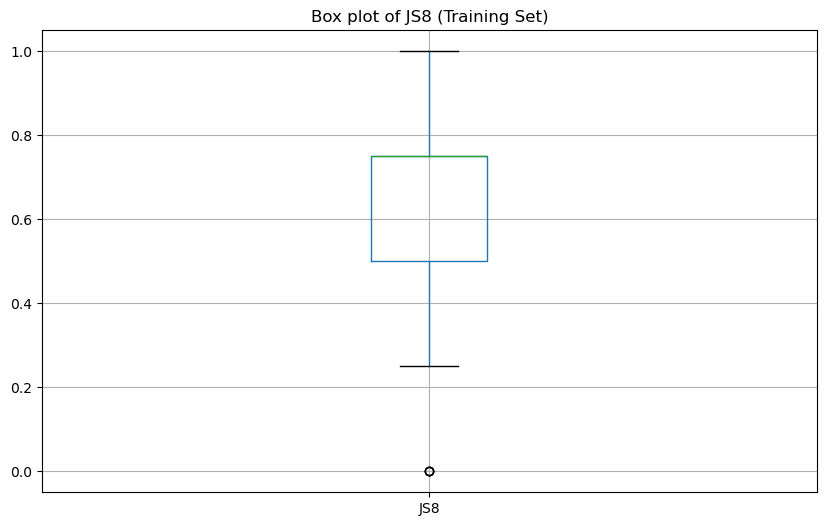

JS9 - Number of Outliers: 103


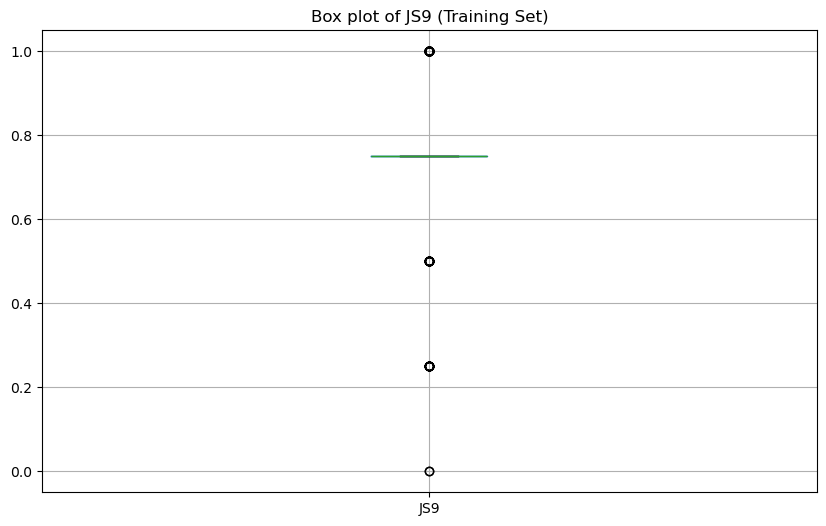

JS10 - Number of Outliers: 25


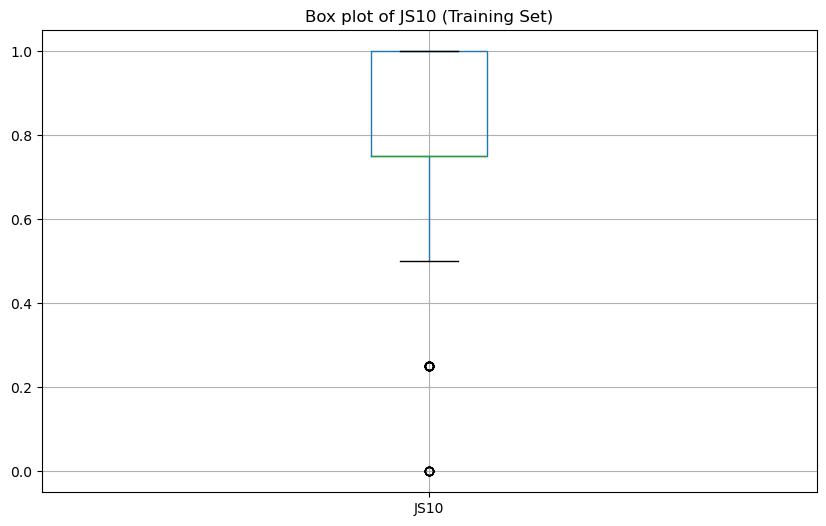

JS11 - Number of Outliers: 8


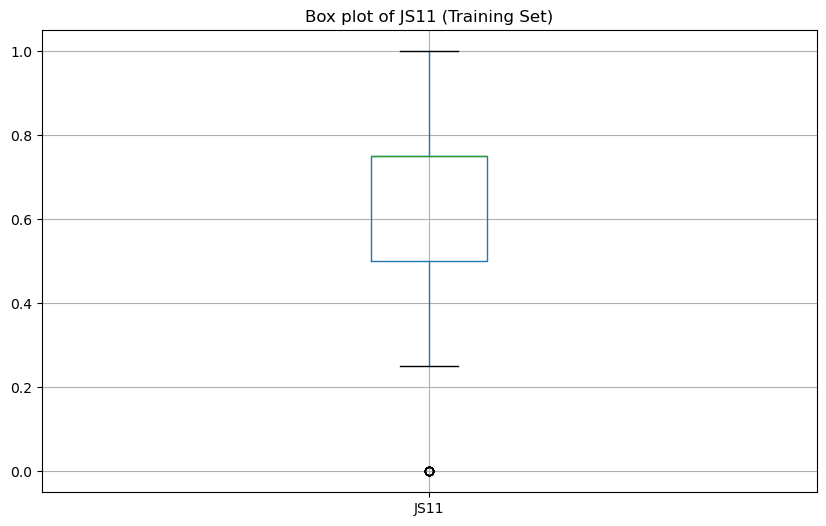

JS12 - Number of Outliers: 8


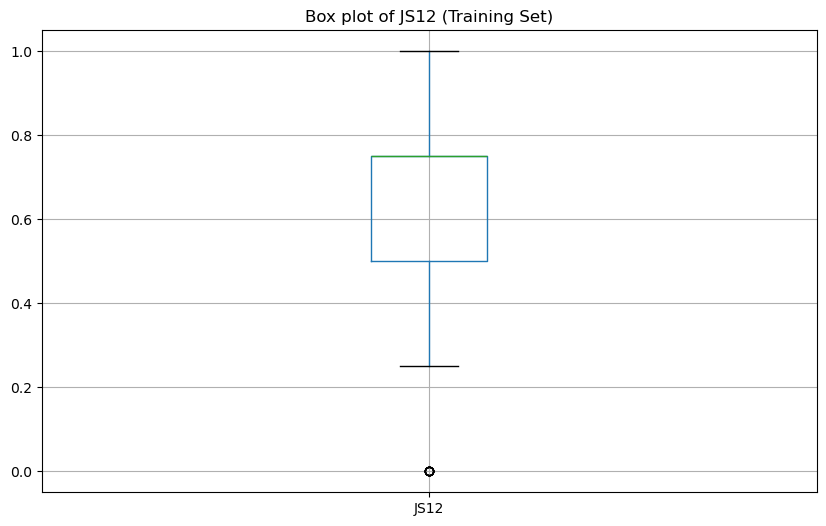

JS13 - Number of Outliers: 6


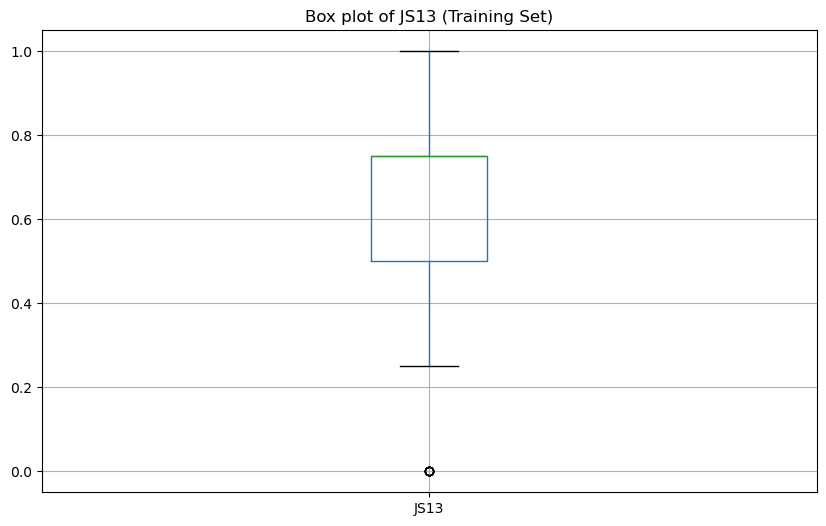

JS14 - Number of Outliers: 6


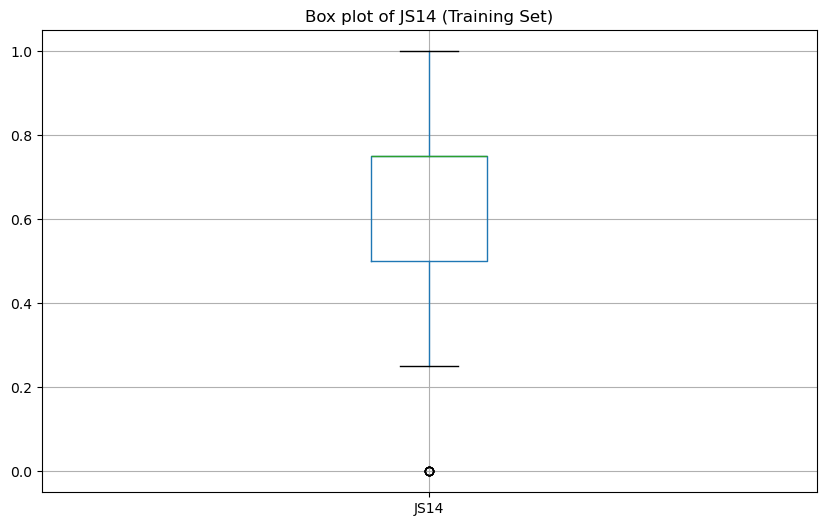

JS15 - Number of Outliers: 0


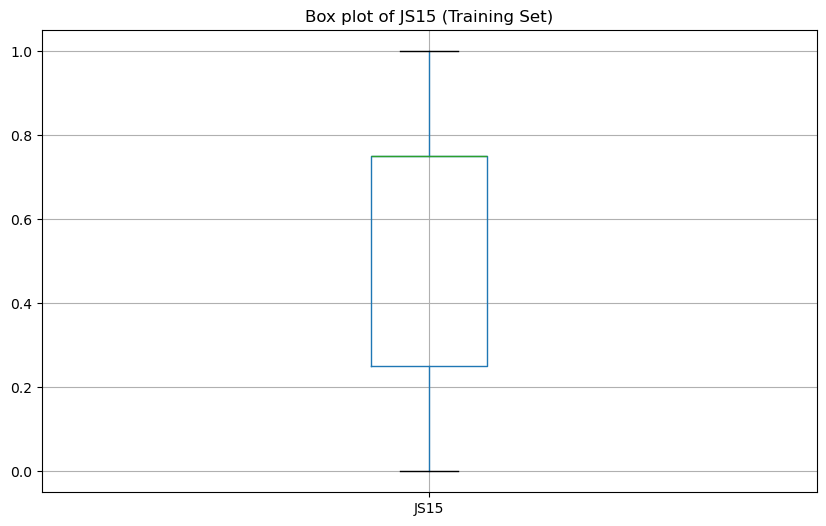

JS16 - Number of Outliers: 8


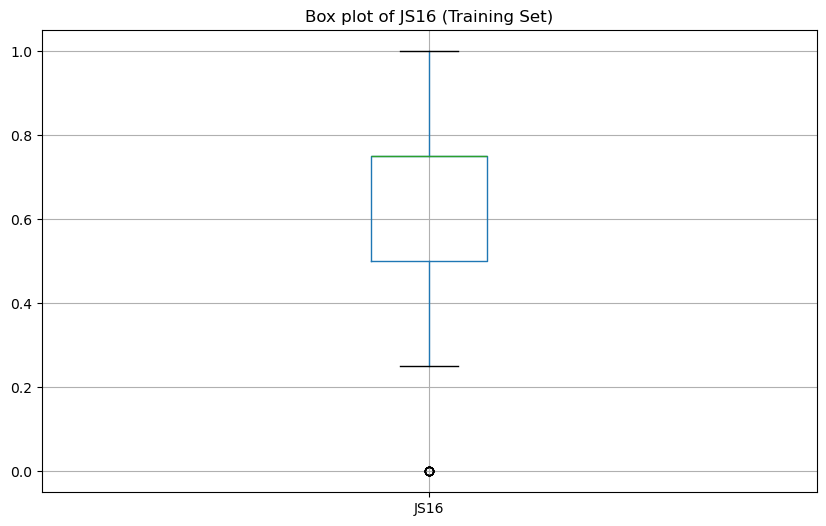

JS17 - Number of Outliers: 3


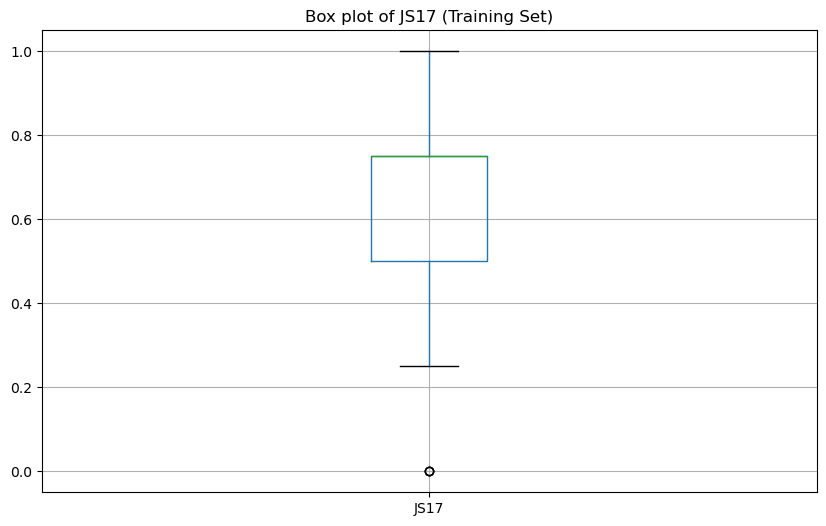

JS18 - Number of Outliers: 17


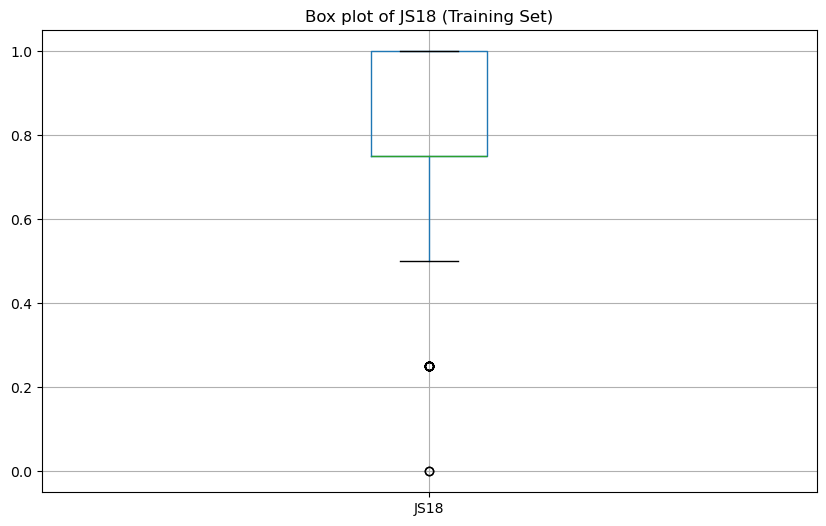

JS19 - Number of Outliers: 4


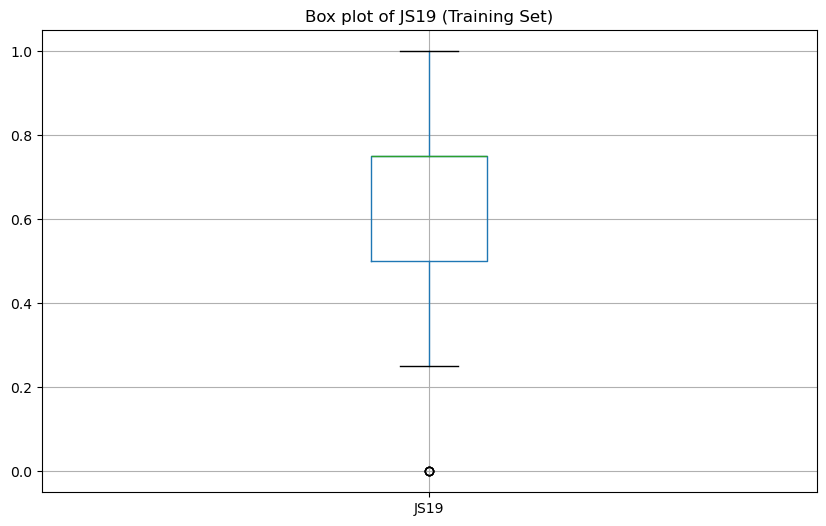

JS20 - Number of Outliers: 4


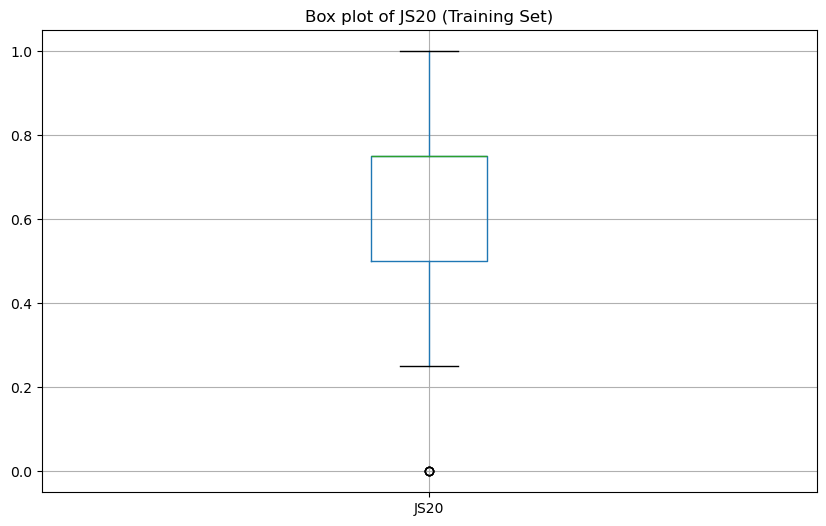

JS21 - Number of Outliers: 0


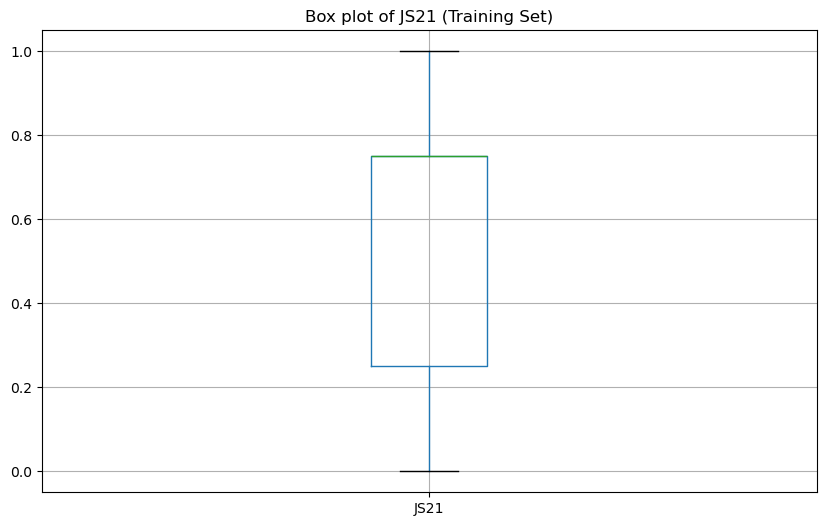

JS22 - Number of Outliers: 0


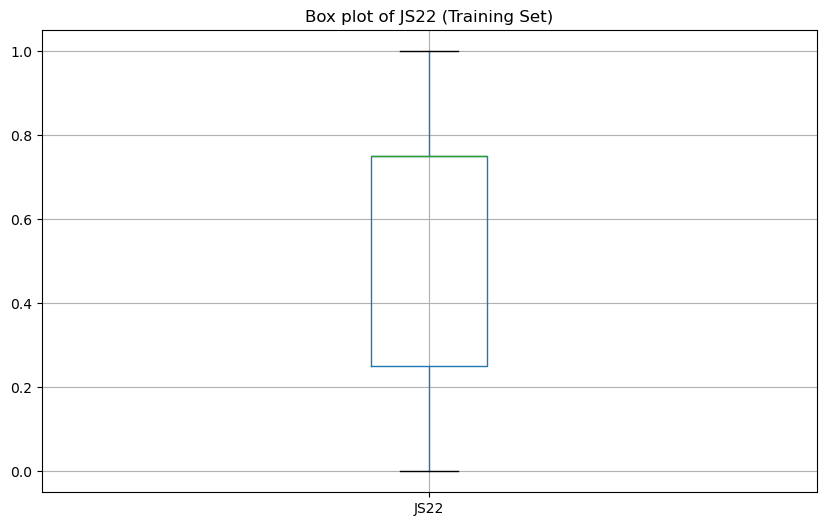

JS23 - Number of Outliers: 0


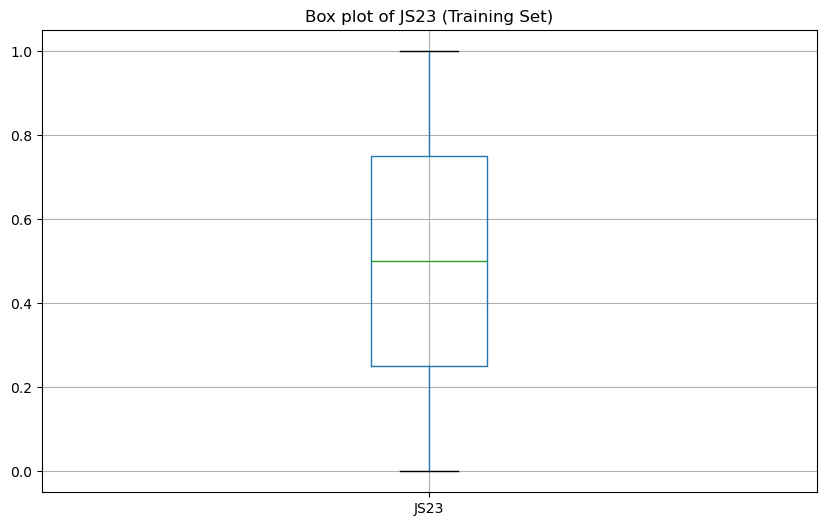

JS24 - Number of Outliers: 0


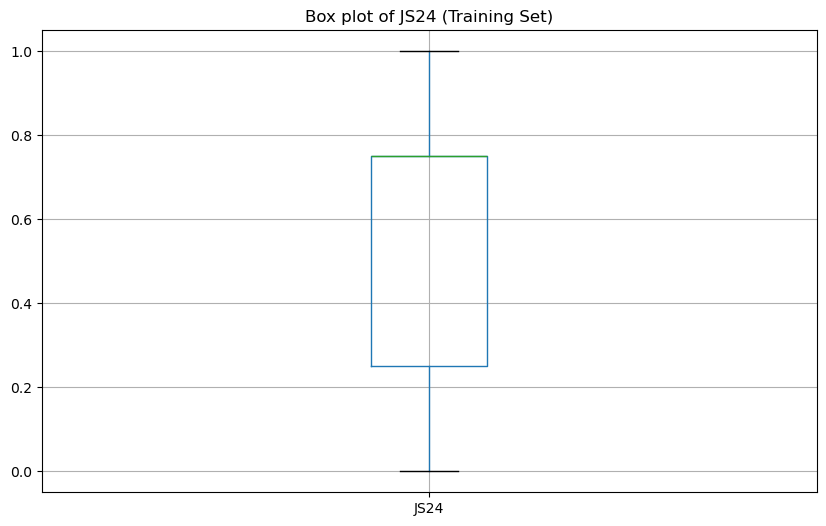

JS25 - Number of Outliers: 8


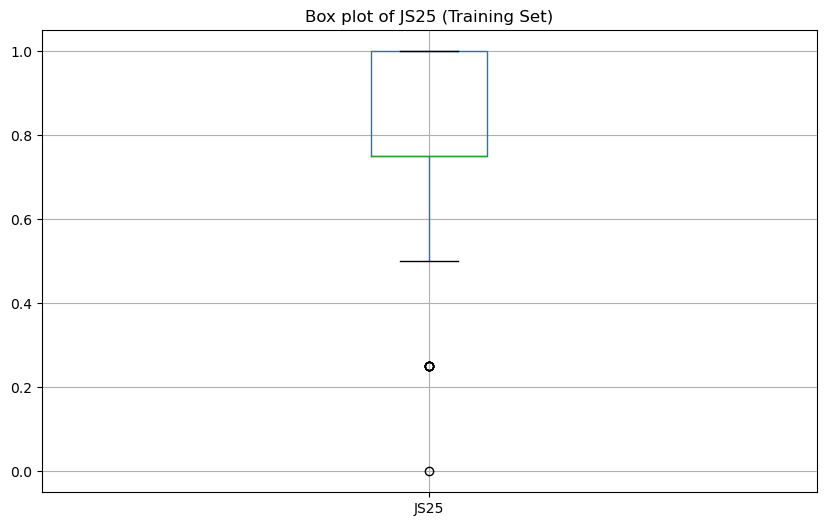

JS26 - Number of Outliers: 8


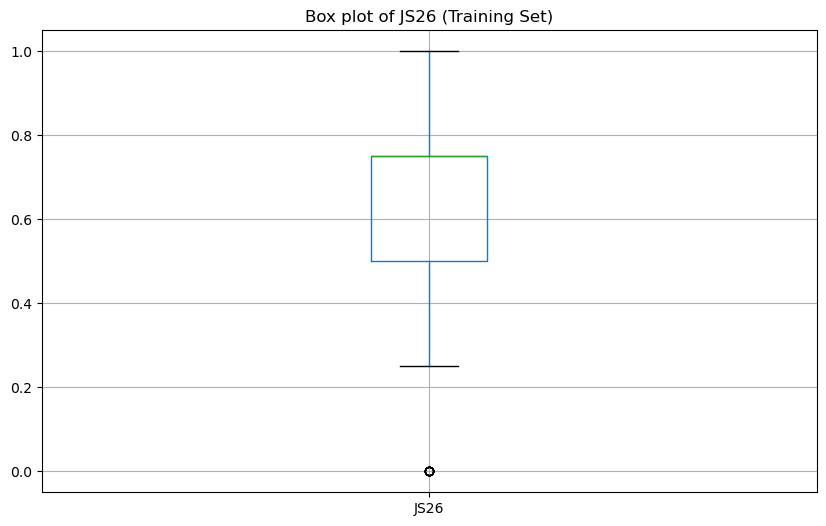

JS27 - Number of Outliers: 92


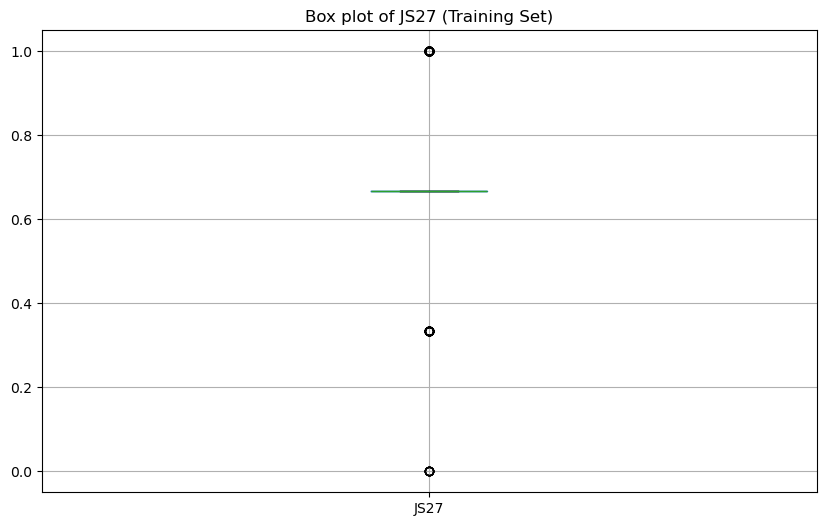

JS28 - Number of Outliers: 30


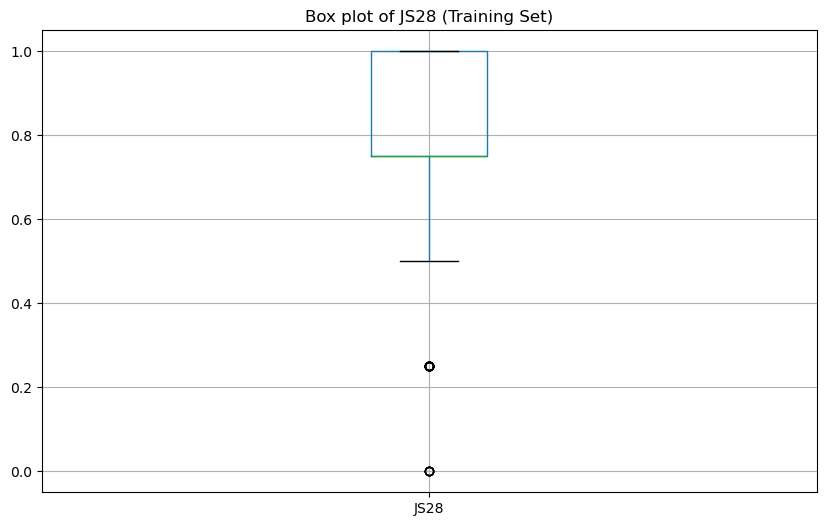

JS29 - Number of Outliers: 28


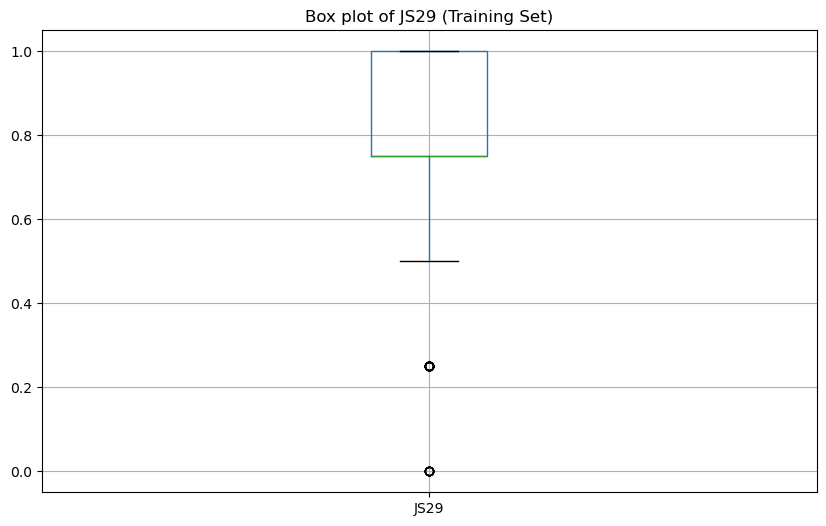

JS30 - Number of Outliers: 5


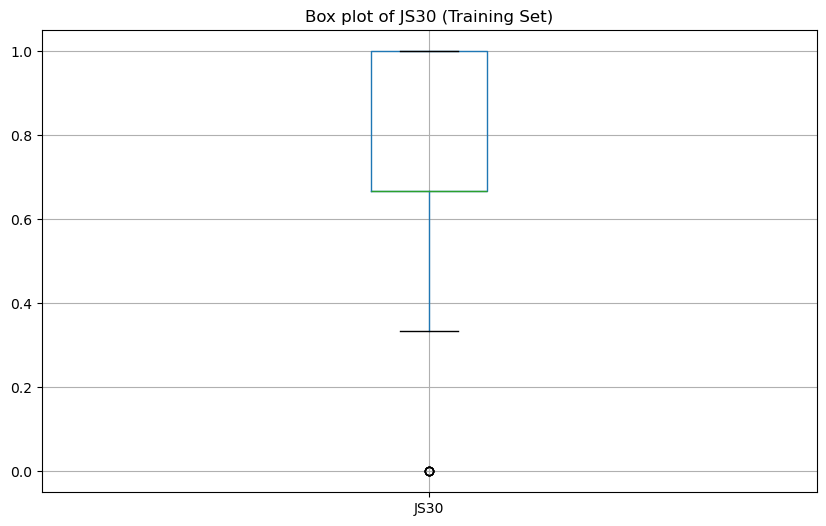

JS31 - Number of Outliers: 5


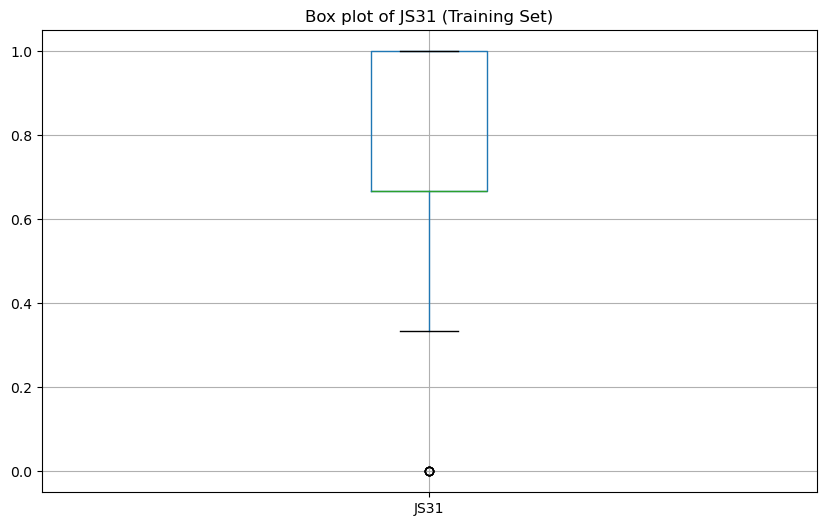

JS32 - Number of Outliers: 11


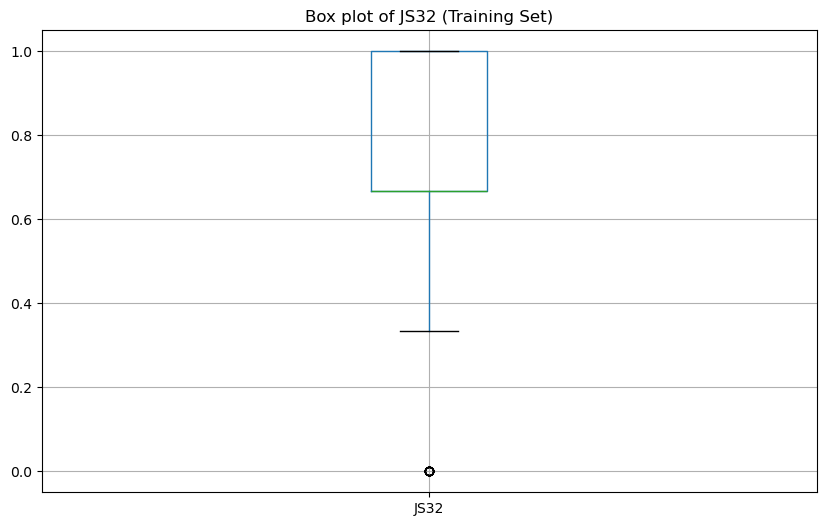

JS33 - Number of Outliers: 48


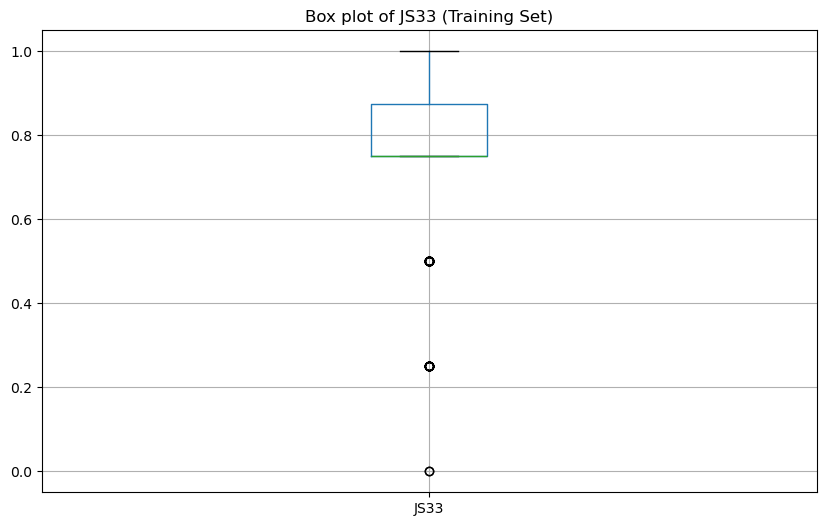

JS34 - Number of Outliers: 24


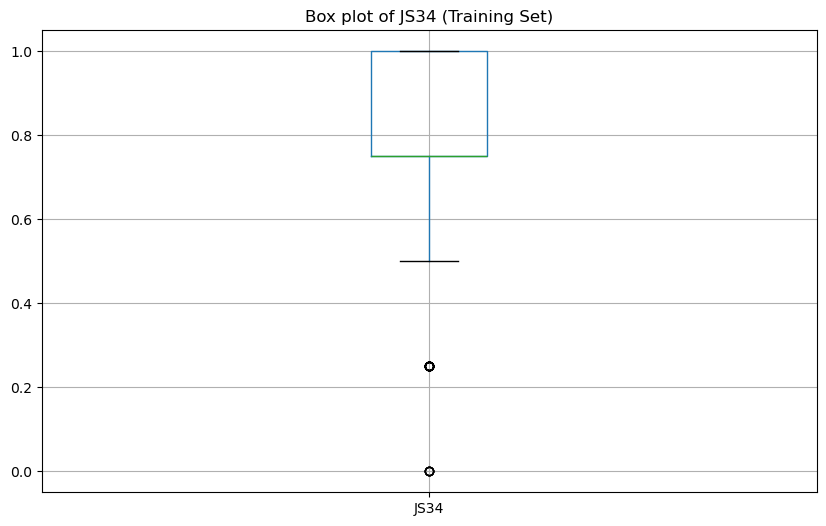

JS35 - Number of Outliers: 4


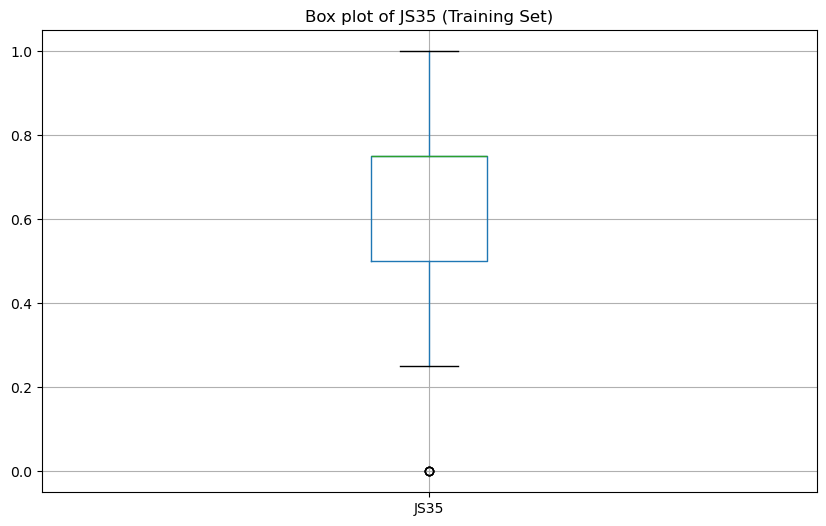

JS36 - Number of Outliers: 5


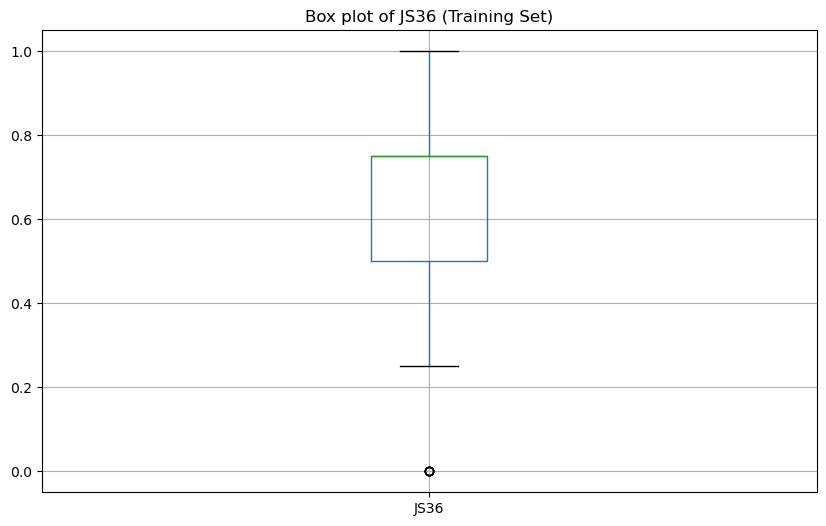

JP1 - Number of Outliers: 7


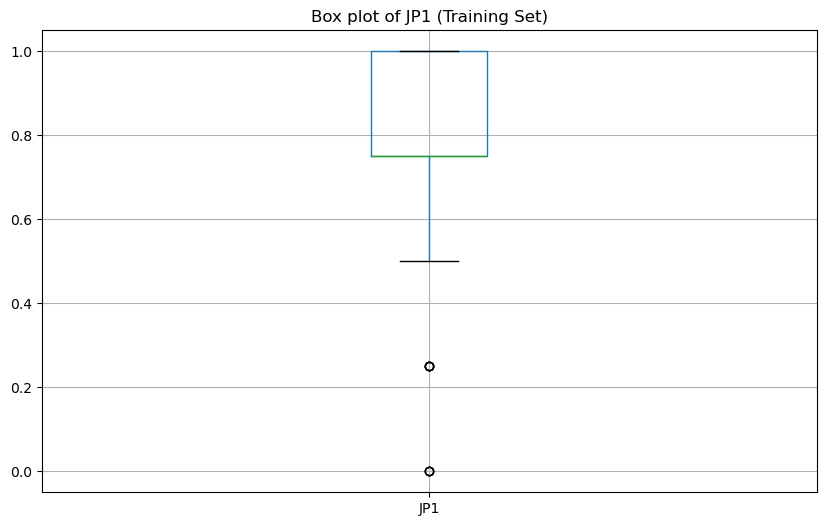

JP2 - Number of Outliers: 6


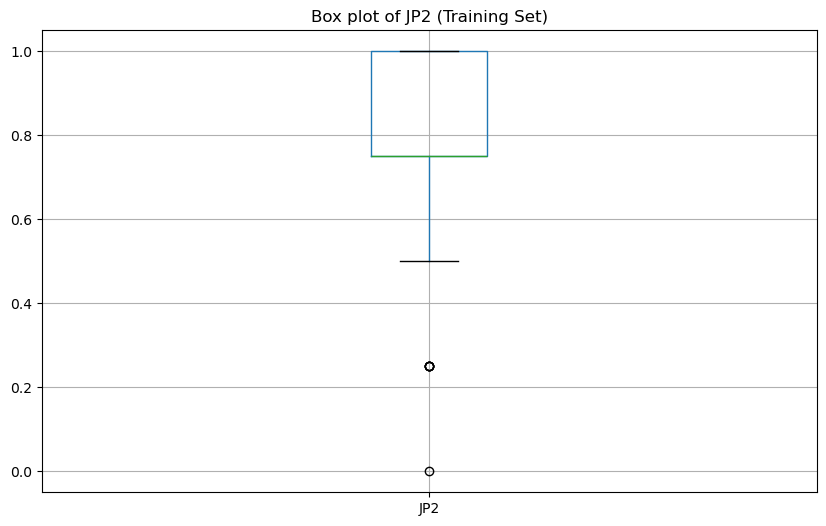

JP3 - Number of Outliers: 16


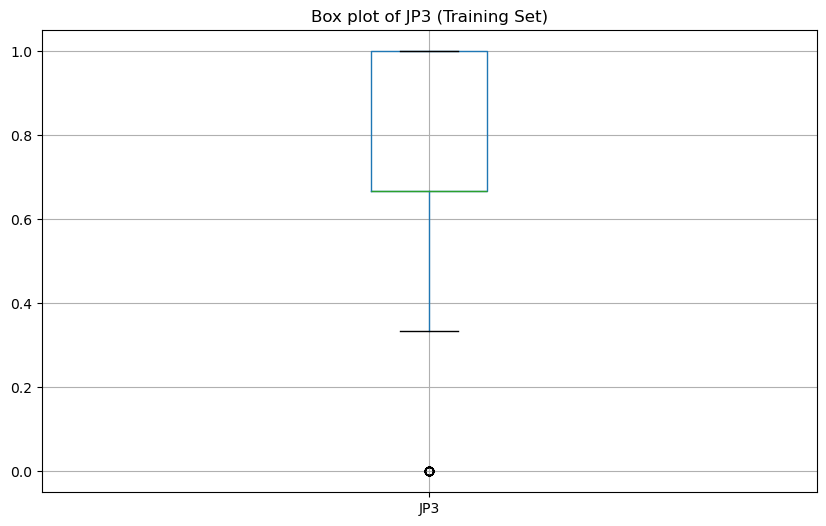

JP4 - Number of Outliers: 25


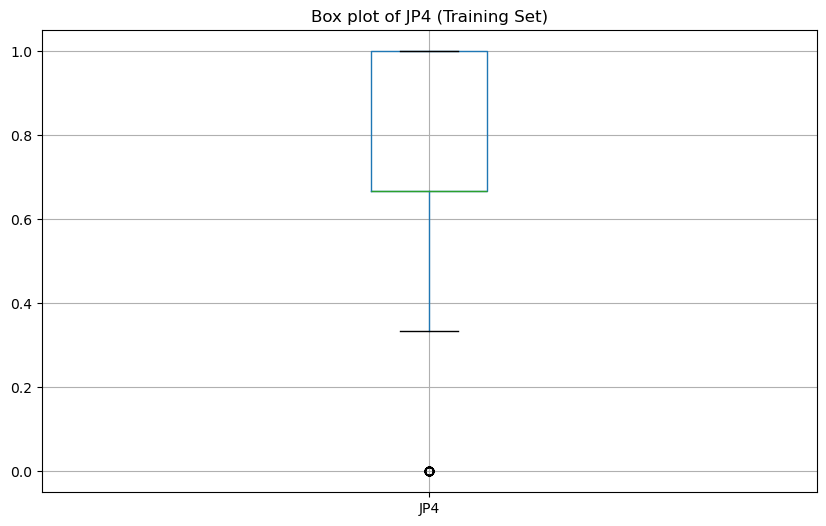

JP5 - Number of Outliers: 12


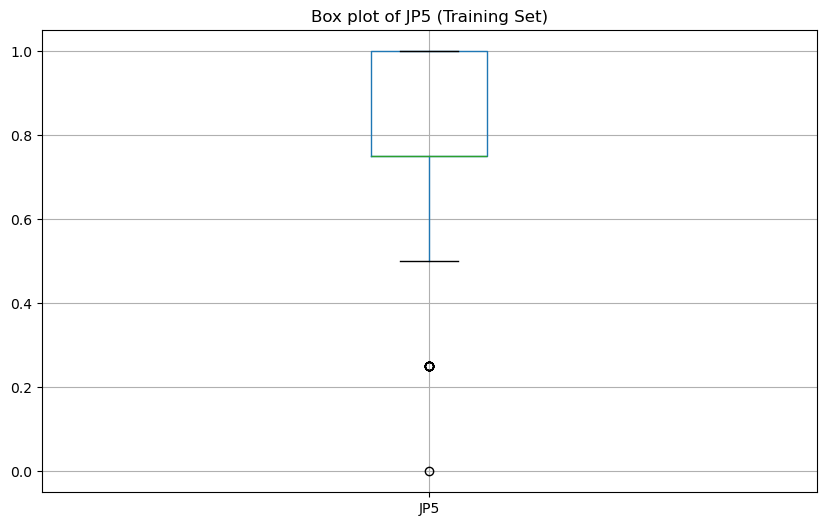

JP6 - Number of Outliers: 3


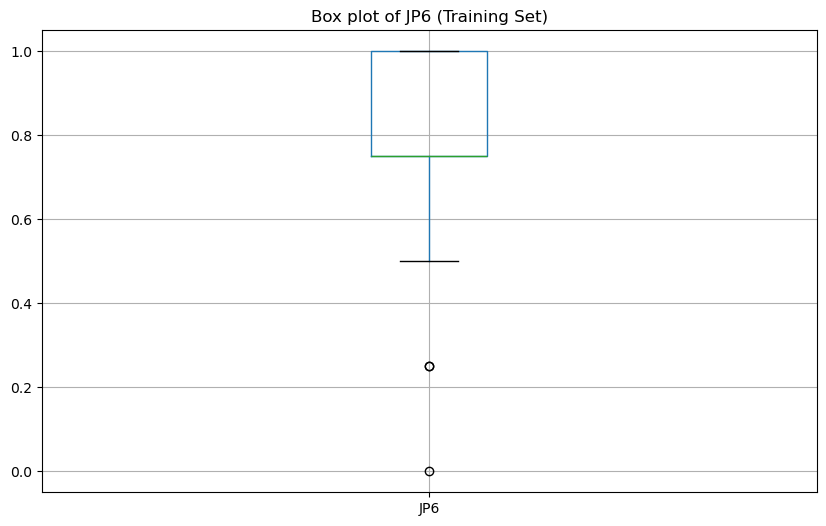

In [14]:
# 이상치 확인 - IQR

for column in X_train.columns:
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR 

    outliers = X_train[(X_train[column] < lower_bound) | (X_train[column] > upper_bound)]
    print(f"{column} - Number of Outliers: {len(outliers)}")

    plt.figure(figsize=(10, 6))
    X_train.boxplot([column])
    plt.title(f"Box plot of {column} (Training Set)")
    plt.show()



In [16]:
# 이상치 처리 - 평균값으로 대체

mean_value = X_train[(X_train[column] >= lower_bound) & (X_train[column] <= upper_bound)][column].mean()
X_train.loc[(X_train[column] < lower_bound) | (X_train[column] > upper_bound), column] = mean_value